In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

In [3]:
nifty = yf.download("^NSEI", start="2014-01-01", end="2024-06-30")
nifty.to_csv("nifty.csv")

[*********************100%***********************]  1 of 1 completed


In [4]:
df = pd.read_csv("nifty.csv", skiprows=[1,2], index_col=0, parse_dates=True)

log_returns = np.log(df['Close'] / df['Close'].shift(1))

df['returns'] = log_returns

df.dropna(inplace=True)

#print(df.head())

df['return_squared'] = df['returns'] ** 2
X = np.column_stack((df['returns'], df['return_squared']))


scaler = StandardScaler()
X = scaler.fit_transform(X)
model = GaussianHMM(n_components=4, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)
regimes = model.predict(X)
df['Regime_new'] = regimes

df.to_csv("regime_labels2.csv")
regime_names = {0: "Bull", 1: "Bear", 2: "HighVol", 3: "Crash"}
df['Regime_label'] = df['Regime_new'].map(regime_names)

In [5]:
df.to_csv("regime_labels_final.csv")

In [6]:
current_state = df['Regime_new']
next_state = df['Regime_new'].shift(-1)

count_matrix = pd.crosstab(current_state, next_state)
P = count_matrix.div(count_matrix.sum(axis=1), axis=0)
print(P)

Regime_new       0.0       1.0       2.0       3.0
Regime_new                                        
0           0.457300  0.421488  0.121212  0.000000
1           0.401685  0.441948  0.156367  0.000000
2           0.392252  0.331719  0.273608  0.002421
3           0.000000  0.000000  1.000000  0.000000


In [7]:
P.to_csv("transition_matrix.csv")

In [8]:
for i in range(4):
    subset = df[df['Regime_new'] == i]['returns']
    # compute mean and variance of subset
    subset_mean = subset.mean()
    subset_var = subset.var()
    print(f"Regime {i}: Mean = {subset_mean:.6f}, Variance = {subset_var:.6f}")

Regime 0: Mean = 0.005512, Variance = 0.000009
Regime 1: Mean = -0.003831, Variance = 0.000011
Regime 2: Mean = -0.001012, Variance = 0.000464
Regime 3: Mean = -0.139038, Variance = nan


In [9]:
regime_stats = {}
for i in range(4):
    subset = df[df['Regime_new'] == i]['returns']
    mean = subset.mean()
    var = subset.var()
    regime_stats[i] = {'mean': mean, 'var': var}

# Shrinkage: Crash borrows from HighVol, scaled
regime_stats[3]['mean'] = regime_stats[2]['mean'] * 2
regime_stats[3]['var'] = regime_stats[2]['var'] * 3

print(regime_stats)

{0: {'mean': np.float64(0.005512319837087575), 'var': np.float64(9.48971554715756e-06)}, 1: {'mean': np.float64(-0.0038311586866553254), 'var': np.float64(1.0873477816961516e-05)}, 2: {'mean': np.float64(-0.0010116936564828708), 'var': np.float64(0.0004644888456624992)}, 3: {'mean': np.float64(-0.0020233873129657416), 'var': np.float64(0.0013934665369874978)}}


In [10]:
import json
with open("regime_stats.json", "w") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in regime_stats.items()}, f, indent=2)
print("saved")

saved


In [11]:
posteriors = model.predict_proba(X)
print(posteriors.shape)

(2572, 4)


In [12]:
P = pd.read_csv("transition_matrix.csv", index_col=0)
P = P.values  # convert to numpy array
print(P.shape)  # should be (4, 4)

(4, 4)


In [13]:
import numpy as np

# current regime distribution (last day)
mu_t = posteriors[-1]
print("Today's regime probs:", mu_t)

# forecast h steps ahead
for h in [1, 5, 10, 30]:
    Ph = np.linalg.matrix_power(P, h)
    mu_th = mu_t @ Ph
    print(f"h={h}: {mu_th}")

Today's regime probs: [1.08657979e-06 9.99290454e-01 7.08459051e-04 0.00000000e+00]
h=1: [4.01678770e-01 4.41869451e-01 1.56450063e-01 1.71539722e-06]
h=5: [4.23570363e-01 4.15402133e-01 1.60638540e-01 3.88964107e-04]
h=10: [4.23570595e-01 4.15402567e-01 1.60637884e-01 3.88953715e-04]
h=30: [4.23570595e-01 4.15402567e-01 1.60637884e-01 3.88953715e-04]


In [14]:
means = np.array([regime_stats[i]['mean'] for i in range(4)])
expected_return = np.dot(mu_th, means)
print(expected_return)

0.0005800801080513571


In [15]:
variances = np.array([regime_stats[i]['var'] for i in range(4)])
expected_var = np.dot(mu_th, variances)
print(expected_var)

8.36929343971067e-05


In [16]:
signal = expected_return / np.sqrt(expected_var)
print(signal)

0.06340792998628658


In [18]:
signals = []
for t in range(len(posteriors)):
    mu_t = posteriors[t]
    mu_t1 = mu_t @ P  # 1-step forecast
    exp_ret = np.dot(mu_t1, means)
    exp_var = np.dot(mu_t1, variances)
    signal = exp_ret / np.sqrt(exp_var)
    signals.append(signal)

signals = np.array(signals)
positions = (signals > 0.05).astype(int)  # 1 = invest, 0 = cash
print(f"Days invested: {positions.sum()} / {len(positions)}")

Days invested: 1536 / 2572


In [19]:
df['position'] = positions
df['strategy_return'] = df['position'].shift(1) * df['returns']  # shift(1) to avoid lookahead
df['buyhold_return'] = df['returns']

# cumulative returns
df['strategy_cum'] = (1 + df['strategy_return']).cumprod()
df['buyhold_cum'] = (1 + df['buyhold_return']).cumprod()

print(f"Strategy final return: {df['strategy_cum'].iloc[-1]:.2f}x")
print(f"Buy & Hold final return: {df['buyhold_cum'].iloc[-1]:.2f}x")

Strategy final return: 4.17x
Buy & Hold final return: 3.35x


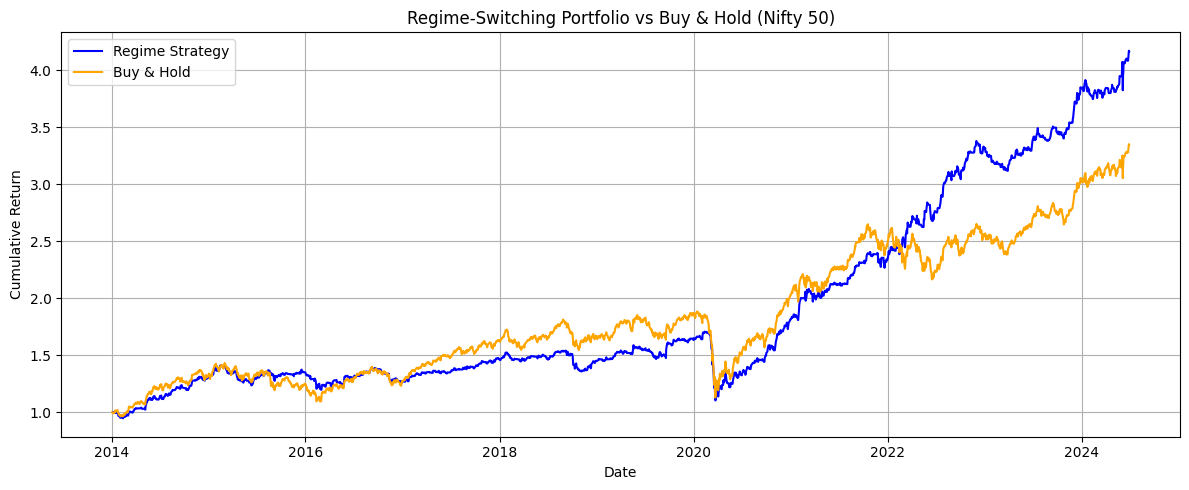

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['strategy_cum'], label='Regime Strategy', color='blue')
plt.plot(df.index, df['buyhold_cum'], label='Buy & Hold', color='orange')
plt.title('Regime-Switching Portfolio vs Buy & Hold (Nifty 50)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("backtest_plot.png", dpi=150)
plt.show()

In [21]:
# Sharpe Ratio (annualized, assuming 252 trading days)
strat_ret = df['strategy_return'].dropna()
sharpe = (strat_ret.mean() / strat_ret.std()) * np.sqrt(252)

# Max Drawdown
rolling_max = df['strategy_cum'].cummax()
drawdown = (df['strategy_cum'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Buy & Hold Sharpe
bh_ret = df['buyhold_return'].dropna()
bh_sharpe = (bh_ret.mean() / bh_ret.std()) * np.sqrt(252)

print(f"Strategy Sharpe: {sharpe:.2f}")
print(f"Buy & Hold Sharpe: {bh_sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

Strategy Sharpe: 1.09
Buy & Hold Sharpe: 0.80
Max Drawdown: -35.35%


In [22]:
bh_rolling_max = df['buyhold_cum'].cummax()
bh_drawdown = (df['buyhold_cum'] - bh_rolling_max) / bh_rolling_max
bh_max_drawdown = bh_drawdown.min()
print(f"Buy & Hold Max Drawdown: {bh_max_drawdown:.2%}")

Buy & Hold Max Drawdown: -40.04%
